# Análise exploratória dos dados

Nesta etapa, a base analítica integrada é explorada para identificar padrões, diferenças entre grupos e evolução temporal dos indicadores educacionais das escolas públicas de Ensino Fundamental de Porto Alegre entre 2018 e 2023.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED = PROJECT_ROOT / "data" / "processed"

base = pd.read_csv(
    PROCESSED / "base_analitica_escola_ano.csv",
    dtype={"codigo_escola": "string"}
)

base["ano"] = pd.to_numeric(
    base["ano"],
    errors="coerce"
).astype("Int64")

print("Dimensão da base:", base.shape)
print("Período:", base["ano"].min(), "-", base["ano"].max())

print("\nEscolas por ano:")
print(
    base.groupby("ano")["codigo_escola"]
    .nunique()
)

print("\nDependência administrativa:")
print(
    base["dependencia_administrativa"]
    .value_counts()
)

print("\nValores ausentes nos principais indicadores:")
print(
    base[
        [
            "taxa_aprovacao",
            "taxa_reprovacao",
            "taxa_abandono",
            "media_alunos_fund"
        ]
    ].isna().sum()
)

display(base.head())

Dimensão da base: (1621, 51)
Período: 2018 - 2023

Escolas por ano:
ano
2018    276
2019    272
2020    271
2021    268
2022    267
2023    267
Name: codigo_escola, dtype: int64

Dependência administrativa:
dependencia_administrativa
Estadual     1285
Municipal     324
Federal        12
Name: count, dtype: int64

Valores ausentes nos principais indicadores:
taxa_aprovacao       50
taxa_reprovacao      50
taxa_abandono        50
media_alunos_fund    48
dtype: int64


,ano,uf,municipio,codigo_municipio,codigo_escola,nome_escola,dependencia_administrativa,localizacao,situacao_funcionamento,IN_AGUA_POTAVEL,...,QT_DOC_FUND_AF,QT_TUR_FUND,QT_TUR_FUND_AI,QT_TUR_FUND_AF,taxa_aprovacao,taxa_reprovacao,taxa_abandono,media_alunos_fund,media_alunos_ai,media_alunos_af
0,2018,RS,Porto Alegre,4314902,43000479,E E IND ENS FUN TUPE PAN,Estadual,1,1,0,...,2,2,0,2,91.7,8.3,0.0,6.0,NaN,NaN
1,2018,RS,Porto Alegre,4314902,43001254,E E IND ENS FUN PINDO POTY,Estadual,1,1,0,...,1,2,1,1,100.0,0.0,0.0,1.5,1.0,NaN
2,2018,RS,Porto Alegre,4314902,43005047,E E IND ENS FUN KA AGUY MIRI,Estadual,1,1,0,...,2,2,0,2,100.0,0.0,0.0,3.0,NaN,NaN
3,2018,RS,Porto Alegre,4314902,43048200,EMEF PORTO NOVO,Municipal,1,1,0,...,8,13,9,4,78.0,22.0,0.0,26.9,26.0,29.0
4,2018,RS,Porto Alegre,4314902,43104932,COLEGIO DE APLICACAO UFRGS,Federal,1,1,0,...,39,12,5,7,88.5,11.5,0.0,24.7,20.0,28.0


## Evolução das taxas de rendimento

São analisadas as médias anuais das taxas de aprovação, reprovação e abandono entre 2018 e 2023, permitindo observar a evolução dos indicadores ao longo do período.

,ano,taxa_aprovacao_media,taxa_reprovacao_media,taxa_abandono_media
0,2018,79.97,19.05,0.98
1,2019,83.61,15.35,1.03
2,2020,99.46,0.13,0.41
3,2021,95.47,0.04,4.49
4,2022,89.16,9.27,1.57
5,2023,89.31,9.31,1.39


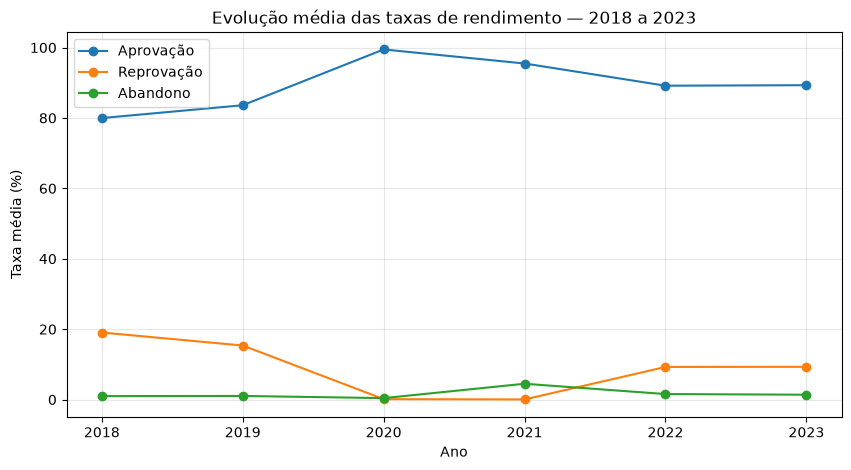

In [3]:
evolucao_rendimento = (
    base.groupby("ano")
    .agg(
        taxa_aprovacao_media=("taxa_aprovacao", "mean"),
        taxa_reprovacao_media=("taxa_reprovacao", "mean"),
        taxa_abandono_media=("taxa_abandono", "mean"),
    )
    .reset_index()
)

display(
    evolucao_rendimento.round(2)
)

plt.figure(figsize=(10, 5))

plt.plot(
    evolucao_rendimento["ano"],
    evolucao_rendimento["taxa_aprovacao_media"],
    marker="o",
    label="Aprovação"
)

plt.plot(
    evolucao_rendimento["ano"],
    evolucao_rendimento["taxa_reprovacao_media"],
    marker="o",
    label="Reprovação"
)

plt.plot(
    evolucao_rendimento["ano"],
    evolucao_rendimento["taxa_abandono_media"],
    marker="o",
    label="Abandono"
)

plt.title("Evolução média das taxas de rendimento — 2018 a 2023")
plt.xlabel("Ano")
plt.ylabel("Taxa média (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Observação sobre o período de 2020 e 2021

Os anos de 2020 e 2021 apresentam comportamento atípico nas taxas de rendimento, com forte aumento da aprovação e redução da reprovação. Esses resultados devem ser interpretados considerando o contexto da pandemia de COVID-19 e possíveis alterações nos critérios e processos de avaliação escolar no período, sem atribuir causalidade diretamente aos fatores escolares analisados.

## Comparação por dependência administrativa

As taxas médias de rendimento são comparadas entre escolas federais, estaduais e municipais, permitindo identificar diferenças de comportamento entre as redes ao longo do período analisado.

,dependencia_administrativa,escolas,taxa_aprovacao_media,taxa_reprovacao_media,taxa_abandono_media
0,Estadual,220,89.12,9.05,1.83
1,Federal,2,95.65,4.35,0.00
2,Municipal,54,90.61,8.52,0.87


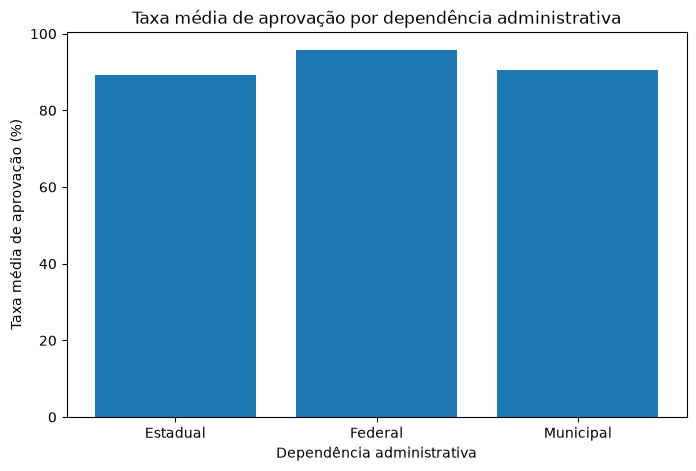

In [4]:
comparacao_dependencia = (
    base.groupby("dependencia_administrativa")
    .agg(
        escolas=("codigo_escola", "nunique"),
        taxa_aprovacao_media=("taxa_aprovacao", "mean"),
        taxa_reprovacao_media=("taxa_reprovacao", "mean"),
        taxa_abandono_media=("taxa_abandono", "mean"),
    )
    .reset_index()
)

display(
    comparacao_dependencia.round(2)
)

plt.figure(figsize=(8, 5))

plt.bar(
    comparacao_dependencia["dependencia_administrativa"],
    comparacao_dependencia["taxa_aprovacao_media"]
)

plt.title("Taxa média de aprovação por dependência administrativa")
plt.xlabel("Dependência administrativa")
plt.ylabel("Taxa média de aprovação (%)")
plt.show()

### Observação

A rede federal apresenta a maior taxa média de aprovação, porém possui apenas duas escolas no recorte analisado. Por isso, seus resultados devem ser interpretados com cautela. Entre as redes com maior número de escolas, a rede municipal apresenta aprovação média ligeiramente superior à estadual.

## Média de alunos por turma e taxa de aprovação

É analisada a relação entre a média de alunos por turma no Ensino Fundamental e a taxa de aprovação, buscando verificar se turmas maiores estão associadas a diferenças no rendimento escolar.

Correlação entre média de alunos por turma e taxa de aprovação: 0.085


,media_alunos_fund,taxa_aprovacao
count,1571.00,1571.00
mean,20.73,89.45
std,5.08,9.37
min,1.00,40.00
25%,18.40,82.80
50%,21.60,91.10
75%,24.30,97.80
max,30.70,100.00


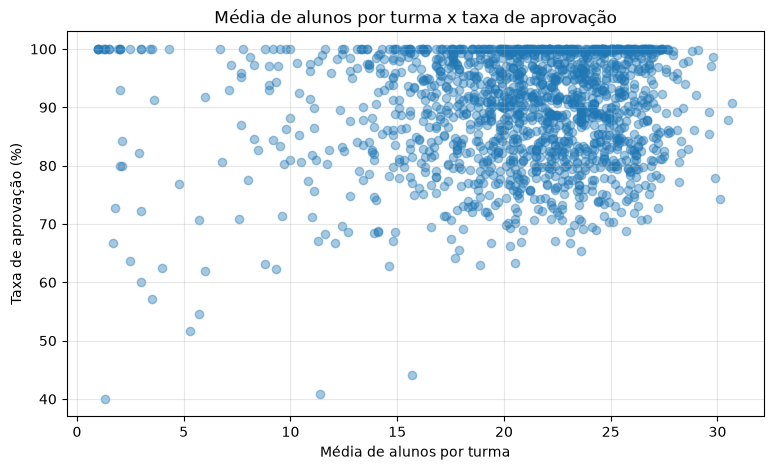

In [5]:
dados_turma = base[
    [
        "ano",
        "codigo_escola",
        "media_alunos_fund",
        "taxa_aprovacao"
    ]
].dropna().copy()

correlacao = dados_turma[
    ["media_alunos_fund", "taxa_aprovacao"]
].corr().loc["media_alunos_fund", "taxa_aprovacao"]

print(
    f"Correlação entre média de alunos por turma "
    f"e taxa de aprovação: {correlacao:.3f}"
)

display(
    dados_turma[
        ["media_alunos_fund", "taxa_aprovacao"]
    ].describe().round(2)
)

plt.figure(figsize=(9, 5))

plt.scatter(
    dados_turma["media_alunos_fund"],
    dados_turma["taxa_aprovacao"],
    alpha=0.4
)

plt.title("Média de alunos por turma x taxa de aprovação")
plt.xlabel("Média de alunos por turma")
plt.ylabel("Taxa de aprovação (%)")
plt.grid(alpha=0.3)

plt.show()

### Resultado

A correlação entre a média de alunos por turma e a taxa de aprovação foi de **0,085**, indicando uma associação linear muito fraca. Neste recorte, não há evidência de uma relação relevante entre turmas maiores e menores taxas de aprovação.

## Infraestrutura escolar e taxa de aprovação

São comparadas as taxas médias de aprovação entre escolas que possuem ou não determinados recursos de infraestrutura, buscando identificar possíveis associações entre condições escolares e rendimento.

In [12]:
variaveis_infraestrutura = [
    "IN_ESGOTO_REDE_PUBLICA",
    "IN_BIBLIOTECA",
    "IN_LABORATORIO_INFORMATICA",
    "IN_INTERNET",
    "IN_BANDA_LARGA",
    "IN_ACESSIBILIDADE_RAMPAS",
]

resultados_ano = []

for variavel in variaveis_infraestrutura:
    tabela = pd.crosstab(
        base["ano"],
        base[variavel],
        dropna=False
    )

    tabela = tabela.reset_index()

    tabela["variavel"] = variavel

    resultados_ano.append(tabela)

infraestrutura_por_ano = pd.concat(
    resultados_ano,
    ignore_index=True
)

display(infraestrutura_por_ano)

,ano,0,1,variavel,NaN
0,2018,15,261,IN_ESGOTO_REDE_PUBLICA,NaN
1,2019,14,258,IN_ESGOTO_REDE_PUBLICA,NaN
2,2020,13,258,IN_ESGOTO_REDE_PUBLICA,NaN
3,2021,13,255,IN_ESGOTO_REDE_PUBLICA,NaN
4,2022,4,263,IN_ESGOTO_REDE_PUBLICA,NaN
5,2023,5,262,IN_ESGOTO_REDE_PUBLICA,NaN
6,2018,56,220,IN_BIBLIOTECA,NaN
7,2019,55,217,IN_BIBLIOTECA,NaN
8,2020,55,216,IN_BIBLIOTECA,NaN
9,2021,31,237,IN_BIBLIOTECA,NaN


### Observações sobre infraestrutura

A análise por ano mostrou que algumas variáveis apresentam mudanças bruscas de padrão ao longo do período, o que indica possível alteração de preenchimento ou de definição entre os layouts do Censo Escolar.

Por esse motivo, `IN_BANHEIRO` e `IN_AGUA_POTAVEL` não serão utilizadas na comparação longitudinal de infraestrutura.

As variáveis com comportamento mais estável ao longo dos anos são:

- esgoto em rede pública;
- biblioteca;
- laboratório de informática;
- internet;
- banda larga;
- rampas de acessibilidade.

Essas variáveis serão mantidas na análise descritiva, sempre com interpretação associativa e não causal.

## Evolução da aprovação por dependência administrativa

A evolução da taxa média de aprovação é analisada separadamente entre as redes Federal, Estadual e Municipal, permitindo observar diferenças de comportamento ao longo do período.

,ano,dependencia_administrativa,escolas,taxa_aprovacao_media
0,2018,Estadual,220,79.74
1,2018,Federal,2,92.35
2,2018,Municipal,54,80.50
3,2019,Estadual,216,83.08
4,2019,Federal,2,95.20
5,2019,Municipal,54,85.39
6,2020,Estadual,215,99.34
7,2020,Federal,2,98.80
8,2020,Municipal,54,100.00
9,2021,Estadual,212,94.95


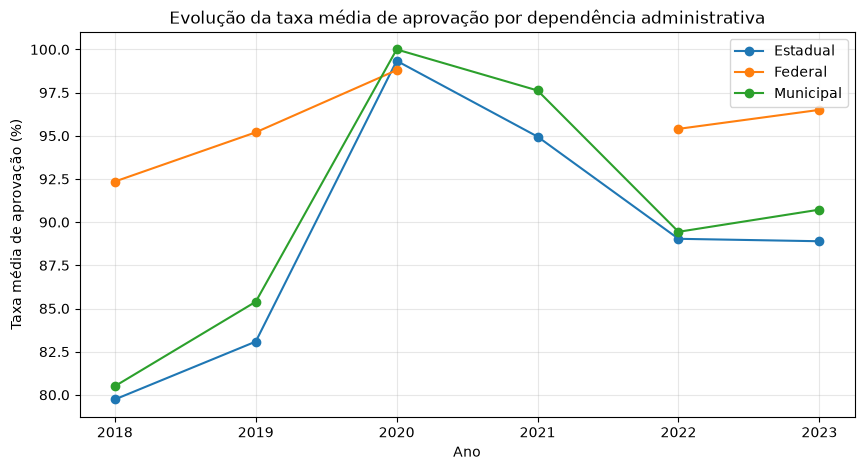

In [13]:
aprovacao_dependencia_ano = (
    base.groupby(
        ["ano", "dependencia_administrativa"]
    )
    .agg(
        escolas=("codigo_escola", "nunique"),
        taxa_aprovacao_media=("taxa_aprovacao", "mean"),
    )
    .reset_index()
)

display(
    aprovacao_dependencia_ano.round(2)
)

plt.figure(figsize=(10, 5))

for dependencia in aprovacao_dependencia_ano["dependencia_administrativa"].unique():

    dados = aprovacao_dependencia_ano[
        aprovacao_dependencia_ano["dependencia_administrativa"] == dependencia
    ]

    plt.plot(
        dados["ano"],
        dados["taxa_aprovacao_media"],
        marker="o",
        label=dependencia
    )

plt.title("Evolução da taxa média de aprovação por dependência administrativa")
plt.xlabel("Ano")
plt.ylabel("Taxa média de aprovação (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Observações

As redes Municipal e Estadual apresentam evolução semelhante ao longo do período, com vantagem média da rede Municipal em vários anos. Os anos de 2020 e 2021 mantêm comportamento atípico, relacionado ao contexto da pandemia. A rede Federal deve ser interpretada com cautela devido ao número reduzido de escolas e à ausência de taxa de aprovação em 2021.

## Distribuição da taxa de aprovação

A distribuição da taxa de aprovação é analisada para identificar concentração, dispersão e possíveis valores extremos entre as escolas ao longo do período.

count    1571.00
mean       89.45
std         9.37
min        40.00
25%        82.80
50%        91.10
75%        97.80
max       100.00
Name: taxa_aprovacao, dtype: float64

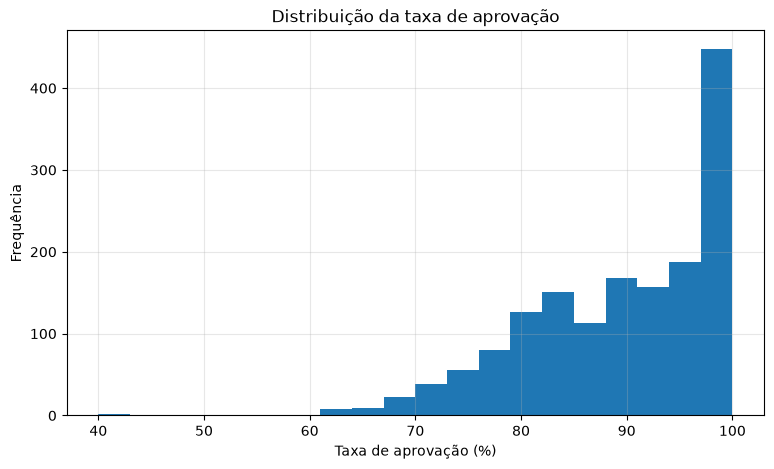

In [14]:
dados_aprovacao = base[
    ["ano", "codigo_escola", "taxa_aprovacao"]
].dropna().copy()

display(
    dados_aprovacao["taxa_aprovacao"]
    .describe()
    .round(2)
)

plt.figure(figsize=(9, 5))

plt.hist(
    dados_aprovacao["taxa_aprovacao"],
    bins=20
)

plt.title("Distribuição da taxa de aprovação")
plt.xlabel("Taxa de aprovação (%)")
plt.ylabel("Frequência")
plt.grid(alpha=0.3)

plt.show()

### Observações

A taxa de aprovação apresenta concentração em valores elevados, com média de 89,45% e mediana de 91,10%. Ainda assim, há dispersão relevante entre as escolas, com registros variando de 40% a 100%, indicando diferenças importantes no rendimento ao longo do período.

## Porte da escola e taxa de aprovação

É analisada a relação entre o número de matrículas no Ensino Fundamental e a taxa de aprovação, buscando verificar se escolas maiores apresentam diferenças no rendimento.

Correlação entre matrículas no Ensino Fundamental e taxa de aprovação: 0.044


,QT_MAT_FUND,taxa_aprovacao
count,1571.00,1571.00
mean,399.04,89.45
std,251.05,9.37
min,1.00,40.00
25%,211.00,82.80
50%,358.00,91.10
75%,508.50,97.80
max,1299.00,100.00


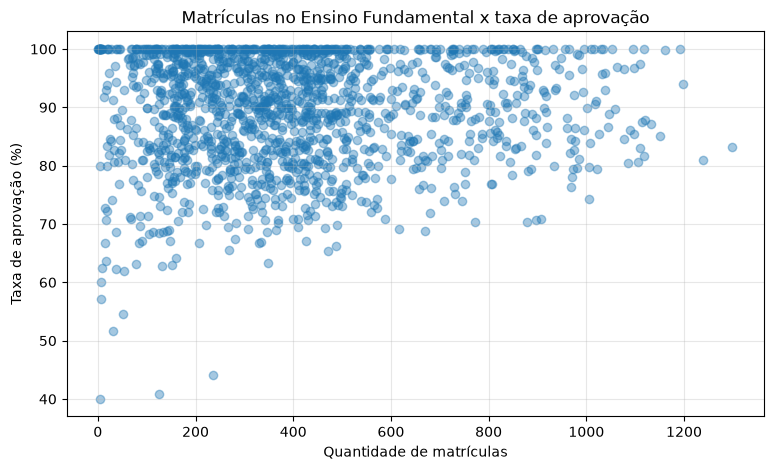

In [15]:

dados_porte = base[
    [
        "QT_MAT_FUND",
        "taxa_aprovacao"
    ]
].dropna().copy()

correlacao_porte = dados_porte[
    ["QT_MAT_FUND", "taxa_aprovacao"]
].corr().loc["QT_MAT_FUND", "taxa_aprovacao"]

print(
    f"Correlação entre matrículas no Ensino Fundamental "
    f"e taxa de aprovação: {correlacao_porte:.3f}"
)

display(
    dados_porte.describe().round(2)
)

plt.figure(figsize=(9, 5))

plt.scatter(
    dados_porte["QT_MAT_FUND"],
    dados_porte["taxa_aprovacao"],
    alpha=0.4
)

plt.title("Matrículas no Ensino Fundamental x taxa de aprovação")
plt.xlabel("Quantidade de matrículas")
plt.ylabel("Taxa de aprovação (%)")
plt.grid(alpha=0.3)

plt.show()

### Observações

A correlação entre o número de matrículas no Ensino Fundamental e a taxa de aprovação foi de 0,044, indicando associação linear praticamente nula. Assim, o porte da escola, isoladamente, não apresenta relação relevante com a aprovação neste recorte.

## Correlação das variáveis numéricas com a taxa de aprovação

São avaliadas as correlações entre a taxa de aprovação e as principais variáveis numéricas da base, buscando identificar associações lineares que possam orientar as próximas etapas da análise.

In [16]:
variaveis_numericas = [
    "taxa_aprovacao",
    "taxa_reprovacao",
    "taxa_abandono",
    "media_alunos_fund",
    "QT_MAT_FUND",
    "QT_DOC_FUND",
    "QT_TUR_FUND",
]

correlacoes = (
    base[variaveis_numericas]
    .corr(numeric_only=True)["taxa_aprovacao"]
    .drop("taxa_aprovacao")
    .sort_values(ascending=False)
)

display(
    correlacoes
    .to_frame("correlacao_com_aprovacao")
    .round(3)
)

,correlacao_com_aprovacao
media_alunos_fund,0.085
QT_DOC_FUND,0.080
QT_MAT_FUND,0.044
QT_TUR_FUND,0.031
taxa_abandono,-0.218
taxa_reprovacao,-0.944


### Observações

As variáveis relacionadas ao porte e à organização escolar apresentam correlações lineares fracas com a taxa de aprovação. A média de alunos por turma e a quantidade de docentes apresentam as maiores correlações positivas, mas ainda muito próximas de zero.

As taxas de reprovação e abandono não são consideradas fatores explicativos, pois fazem parte do mesmo conjunto de indicadores de rendimento da taxa de aprovação e possuem relação matemática direta com ela.

## Taxa de aprovação por período

Para auxiliar a interpretação da série histórica, os anos são agrupados em três períodos: pré-pandemia (2018–2019), pandemia (2020–2021) e pós-pandemia (2022–2023).

In [17]:
def classificar_periodo(ano):
    if ano <= 2019:
        return "Pré-pandemia"
    elif ano <= 2021:
        return "Pandemia"
    else:
        return "Pós-pandemia"

base["periodo"] = base["ano"].apply(classificar_periodo)

resumo_periodo = (
    base.groupby("periodo")
    .agg(
        registros=("codigo_escola", "size"),
        taxa_aprovacao_media=("taxa_aprovacao", "mean"),
        taxa_reprovacao_media=("taxa_reprovacao", "mean"),
        taxa_abandono_media=("taxa_abandono", "mean"),
    )
    .reindex(["Pré-pandemia", "Pandemia", "Pós-pandemia"])
    .reset_index()
)

display(resumo_periodo.round(2))

,periodo,registros,taxa_aprovacao_media,taxa_reprovacao_media,taxa_abandono_media
0,Pré-pandemia,548,81.78,17.21,1.01
1,Pandemia,539,97.48,0.08,2.43
2,Pós-pandemia,534,89.23,9.29,1.48


### Observações

O período da pandemia apresenta comportamento muito diferente dos demais, com forte elevação da taxa média de aprovação e queda acentuada da reprovação. No pós-pandemia, os indicadores retornam a níveis mais próximos do período anterior, embora a aprovação permaneça superior à média pré-pandemia.

Essas diferenças devem ser interpretadas com cautela, pois refletem um contexto excepcional e não permitem atribuir causalidade direta às características escolares.

## Síntese das hipóteses exploratórias

A análise exploratória permitiu avaliar, de forma descritiva, parte das hipóteses definidas no projeto.

- **Infraestrutura:** algumas variáveis apresentam diferenças nas taxas médias de aprovação, mas parte dos indicadores mostrou problemas de comparabilidade entre anos.
- **Recursos pedagógicos e tecnológicos:** biblioteca, laboratório de informática e internet apresentam diferenças pequenas a moderadas entre os grupos.
- **Acessibilidade e serviços básicos:** algumas variáveis, como rampas e esgoto, apresentam diferenças descritivas, sem evidência de causalidade.
- **Média de alunos por turma:** a correlação com a taxa de aprovação foi muito fraca (`0,085`).
- **Porte da escola:** a correlação entre quantidade de matrículas e aprovação foi praticamente nula (`0,044`).
- **Dependência administrativa:** as redes Municipal e Estadual apresentam comportamentos próximos, com vantagem média da rede Municipal em vários anos.
- **Período temporal:** 2020 e 2021 apresentam comportamento atípico nas taxas de rendimento e devem ser analisados separadamente na interpretação dos resultados.

Esses resultados são exploratórios e servirão de base para a construção dos indicadores e para a etapa de modelagem.